# Import Library

In [1]:
!pip install tensorflow

In [2]:
import math
import random
import pickle
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import kagglehub
import time
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    label_ranking_average_precision_score,
    label_ranking_loss,
    coverage_error)
from sklearn.utils import shuffle
from scipy.signal import resample
from sklearn.preprocessing import OneHotEncoder
from keras.models import Model
from keras.layers import (
    Input,
    Dense,
    Conv1D,
    MaxPooling1D,
    Softmax,
    Add,
    Flatten,
    Activation,
    Dropout,
    GlobalAveragePooling1D,
    LayerNormalization,
    MultiHeadAttention,
    Embedding,
    Layer,
    Bidirectional,
    LSTM)
from keras import backend as K
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint

np.random.seed(42)

# Exploratory Data Analysis - EDA

## Membaca Data

In [3]:
# Download latest version
path = kagglehub.dataset_download("shayanfazeli/heartbeat")
print("Path to dataset files:", path)

df1 = pd.read_csv(os.path.join(path, "mitbih_train.csv"), header=None)
df2 = pd.read_csv(os.path.join(path, "mitbih_test.csv"), header=None)
df = pd.concat([df1, df2])

100%|██████████| 98.8M/98.8M [00:00<00:00, 250MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shayanfazeli/heartbeat/versions/1


In [4]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Visualisasi Sinyal

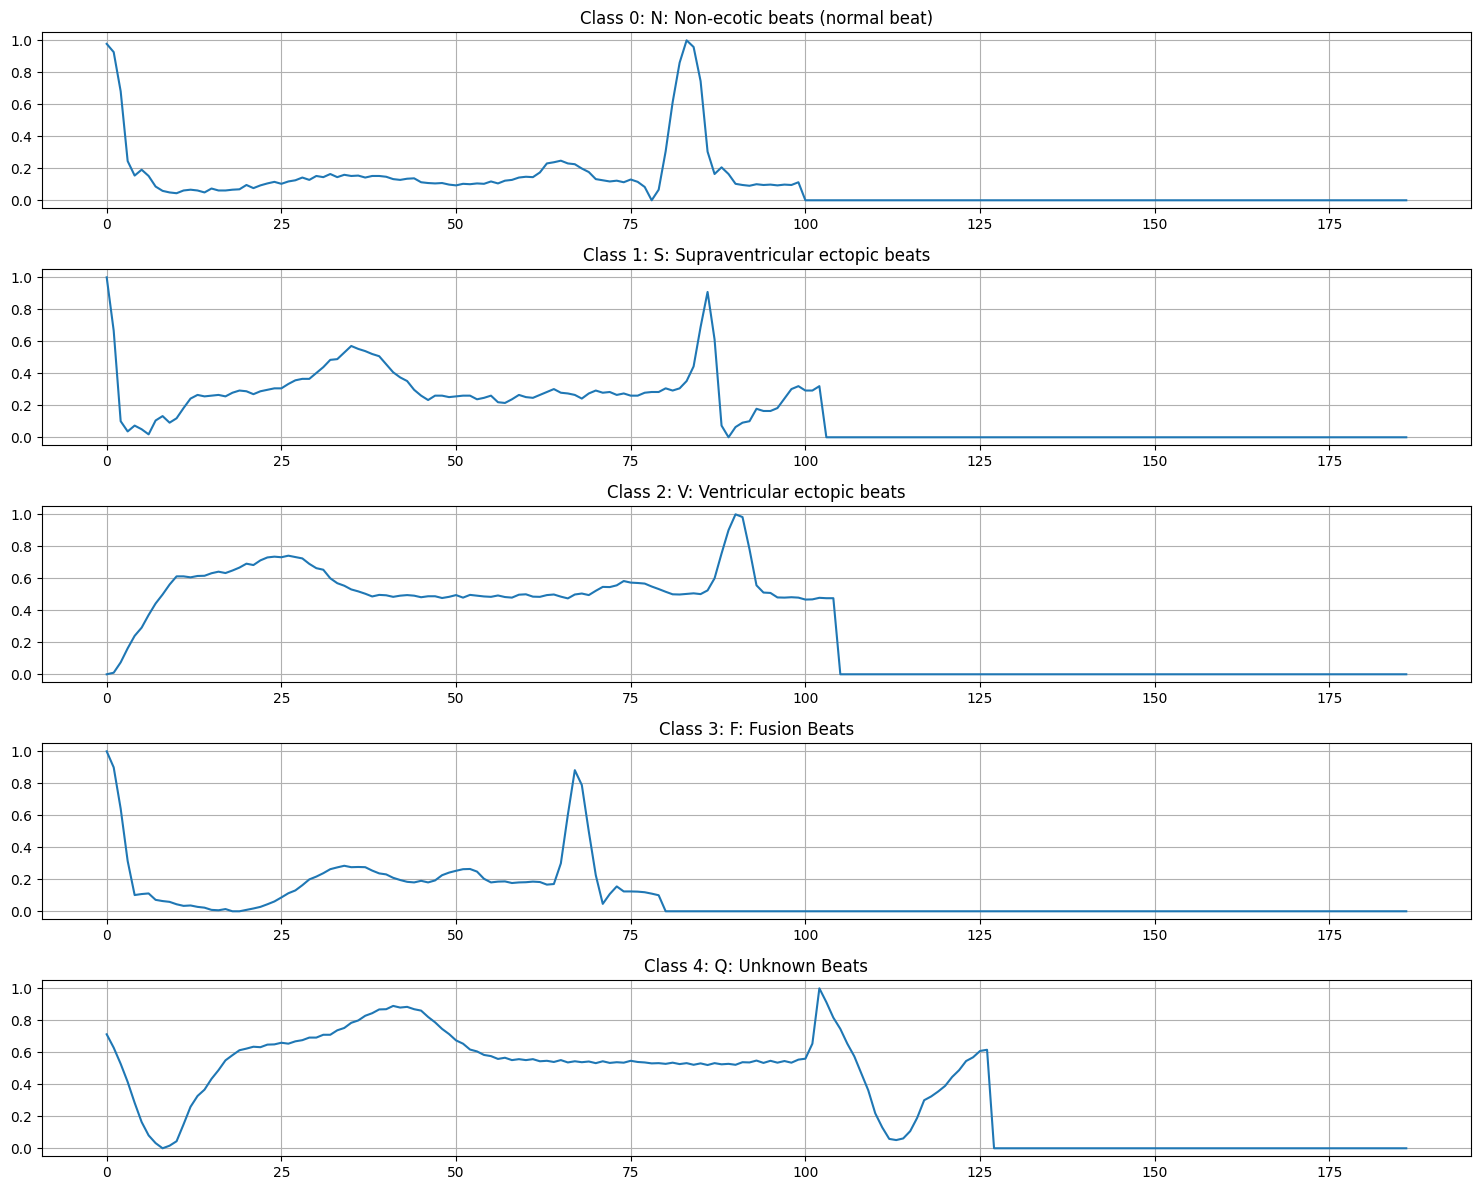

In [5]:
classes = [0, 1, 2, 3, 4]
labels = [
    'N: Non-ecotic beats (normal beat)',
    'S: Supraventricular ectopic beats',
    'V: Ventricular ectopic beats',
    'F: Fusion Beats',
    'Q: Unknown Beats'
]

plt.figure(figsize=(15, 12))

for i, cls in enumerate(classes):
    # Ambil sampel pertama untuk setiap kelas
    sample = df[df[187] == cls].iloc[0, :187]

    plt.subplot(5, 1, i + 1)
    plt.plot(sample)
    plt.title(f"Class {cls}: {labels[i]}")
    plt.grid(True)

plt.tight_layout()
plt.show()

## Analisis Distribusi Kelas

Jumlah sampel per kelas:
187
0.0    90589
1.0     2779
2.0     7236
3.0      803
4.0     8039
Name: count, dtype: int64


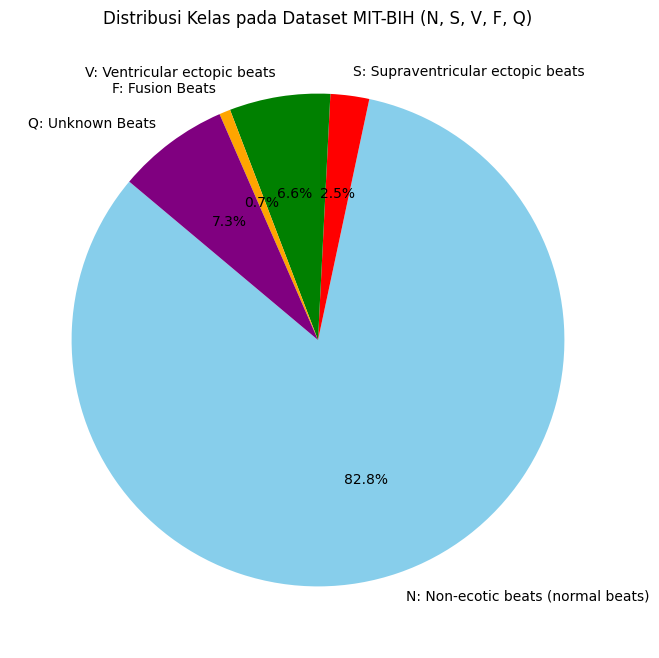

In [6]:
count_classes = df[187].value_counts().sort_index()
print("Jumlah sampel per kelas:")
print(count_classes)

labels_detailed = [
    'N: Non-ecotic beats (normal beats)',
    'S: Supraventricular ectopic beats',
    'V: Ventricular ectopic beats',
    'F: Fusion Beats',
    'Q: Unknown Beats'
]

plt.figure(figsize=(10, 8))
plt.pie(count_classes, labels=labels_detailed, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'red', 'green', 'orange', 'purple'])
plt.title("Distribusi Kelas pada Dataset MIT-BIH (N, S, V, F, Q)")
plt.show()

# Data Preprocessing

## Pemisahan Fitur dan Target

In [7]:
X = df.iloc[:, :187].values
y = df.iloc[:, 187].values

print("Ukuran Fitur (X):", X.shape)
print("Ukuran Target (y):", y.shape)

Ukuran Fitur (X): (109446, 187)
Ukuran Target (y): (109446,)


## Penanganan Data Tidak Seimbang

In [8]:
def resample_dataset(df):
    # Pisahkan setiap kelas
    df_0 = df[df[187] == 0]
    df_1 = df[df[187] == 1]
    df_2 = df[df[187] == 2]
    df_3 = df[df[187] == 3]
    df_4 = df[df[187] == 4]

    # Target jumlah sampel per kelas
    target_samples = 20000

    # Resampling untuk setiap kelas
    df_0_resampled = df_0.sample(n=target_samples, random_state=42) # Undersampling
    df_1_resampled = df_1.sample(n=target_samples, replace=True, random_state=42) # Oversampling
    df_2_resampled = df_2.sample(n=target_samples, replace=True, random_state=42) # Oversampling
    df_3_resampled = df_3.sample(n=target_samples, replace=True, random_state=42) # Oversampling
    df_4_resampled = df_4.sample(n=target_samples, replace=True, random_state=42) # Oversampling

    # Gabungkan kembali
    df_resampled = pd.concat([df_0_resampled, df_1_resampled, df_2_resampled, df_3_resampled, df_4_resampled])
    return df_resampled

# Terapkan resampling
df_balanced = resample_dataset(df)

# Update X dan y dengan data yang sudah seimbang
X_balanced = df_balanced.iloc[:, :187].values
y_balanced = df_balanced.iloc[:, 187].values

print("Distribusi kelas setelah resampling:")
print(df_balanced[187].value_counts().sort_index())
print("\nUkuran X_balanced:", X_balanced.shape)

Distribusi kelas setelah resampling:
187
0.0    20000
1.0    20000
2.0    20000
3.0    20000
4.0    20000
Name: count, dtype: int64

Ukuran X_balanced: (100000, 187)


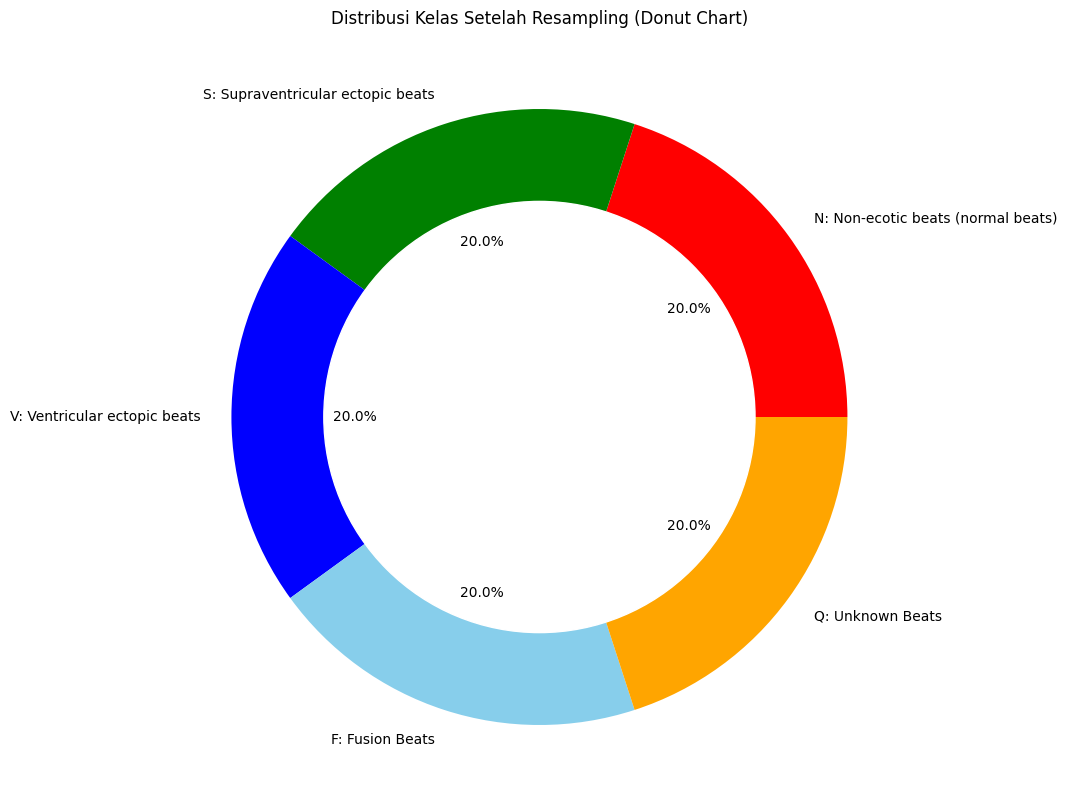

In [9]:
equilibre = df_balanced[187].value_counts()

labels_detailed = [
    'N: Non-ecotic beats (normal beats)',
    'S: Supraventricular ectopic beats',
    'V: Ventricular ectopic beats',
    'F: Fusion Beats',
    'Q: Unknown Beats'
]

plt.figure(figsize=(20,10))
my_circle = plt.Circle((0,0), 0.7, color='white')
plt.pie(equilibre, labels=labels_detailed, colors=['red','green','blue','skyblue','orange'], autopct='%1.1f%%')
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.title("Distribusi Kelas Setelah Resampling (Donut Chart)")
plt.show()

## Reshaping Data

In [10]:
# Reshaping data fitur dari 2D (100000, 187) menjadi 3D (100000, 187, 1)
X_3d = X_balanced.reshape(X_balanced.shape[0], X_balanced.shape[1], 1)

print("Ukuran X_balanced awal:", X_balanced.shape)
print("Ukuran X setelah Reshape (X_3d):", X_3d.shape)

Ukuran X_balanced awal: (100000, 187)
Ukuran X setelah Reshape (X_3d): (100000, 187, 1)


# Pembangunan Model (Vision Transformer 1D)

In [11]:
# 1. One-hot Encoding untuk Target
ohe = OneHotEncoder()
y_balanced_ohe = ohe.fit_transform(y_balanced.reshape(-1, 1)).toarray()

# 2. Definisi Arsitektur TimesNet yang Lebih Ringan
import tensorflow as tf
from keras.layers import Reshape, Permute, Conv2D, GlobalAveragePooling2D, Dense, Input, Dropout, Conv1D, LayerNormalization, GlobalAveragePooling1D, Lambda, Concatenate, Add
from keras.models import Model
import keras.ops as ops

def times_block(inputs, seq_len, k, model_dim):
    # Menghitung periode
    period = seq_len // k
    if period == 0: period = 1
    new_seq_len = period * k

    # Truncate agar bisa di-reshape menggunakan Keras Ops agar tetap symbolic
    x = Lambda(lambda z: z[:, :new_seq_len, :])(inputs)

    # Reshape ke 2D
    x = Reshape((k, period, model_dim))(x)

    # 2D Convolutions (Lightweight: fewer filters or smaller kernel could be used, keeping 3x3 for pattern capture)
    x = Conv2D(model_dim, kernel_size=(3, 3), padding="same", activation="gelu")(x)
    x = LayerNormalization()(x)

    # Reshape kembali ke 1D
    x = Reshape((new_seq_len, model_dim))(x)

    # Padding menggunakan Lambda untuk menghindari ValueError KerasTensor
    if new_seq_len < seq_len:
        diff = seq_len - new_seq_len
        padding = Lambda(lambda z: ops.cast(ops.zeros((ops.shape(z)[0], diff, model_dim)), z.dtype))(inputs)
        x = Concatenate(axis=1)([x, padding])

    # Residual connection
    return Add()([x, inputs])

def build_timesnet_light(
    input_shape=(187, 1),
    num_classes=5,
    num_layers=1,     # Dikurangi dari 2
    model_dim=32,     # Dikurangi dari 64
    top_k=2,          # Dikurangi dari 3
    dropout=0.1
):
    inputs = Input(shape=input_shape)

    # Embedding
    x = Conv1D(filters=model_dim, kernel_size=3, padding="same")(inputs)

    # TimesBlocks
    for _ in range(num_layers):
        for k in range(1, top_k + 1):
            x = times_block(x, input_shape[0], k, model_dim)
        x = Dropout(dropout)(x)

    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation="relu")(x) # Dikurangi dari 128
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Inisialisasi Model TimesNet Ringan
timesnet_model = build_timesnet_light(
    input_shape=(187, 1),
    num_layers=1,
    model_dim=32,
    top_k=2
)

timesnet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 187, 32)   │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 187, 32)   │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 187,    │          0 │ lambda[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 1, 187,    │      9,248 │ reshape[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 187,    │         64 │ conv2d[0][0]      │
│ (LayerNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 187, 32)   │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 187, 32)   │          0 │ reshape_1[0][0],  │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 186, 32)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 2, 93, 32) │          0 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 2, 93, 32) │      9,248 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 2, 93, 32) │         64 │ conv2d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 186, 32)   │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1, 32)     │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 187, 32)   │          0 │ reshape_3[0][0],  │
│ (Concatenate)       │                   │            │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 187, 32)   │          0 │ concatenate[0][0… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 187, 32)   │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ dropout[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      2,112 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │        325 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 21,189 (82.77 KB)

 Trainable params: 21,189 (82.77 KB)

 Non-trainable params: 0 (0.00 B)

## Split Data

In [12]:
# Tahap 1: Split 70% Training dan 30% Sisa (Val + Test)
X_train, X_rem, y_train, y_rem = train_test_split(
    X_3d, y_balanced_ohe, test_size=0.3, random_state=42, stratify=y_balanced_ohe
)

# Tahap 2: Split Sisa (30%) menjadi 50% Val dan 50% Test (sehingga masing-masing 15% dari total)
X_val, X_test, y_val, y_test = train_test_split(
    X_rem, y_rem, test_size=0.5, random_state=42, stratify=y_rem
)

print(f"X_train shape: {X_train.shape} (70%)")
print(f"X_val shape:   {X_val.shape} (15%)")
print(f"X_test shape:  {X_test.shape} (15%)")

X_train shape: (70000, 187, 1) (70%)
X_val shape:   (15000, 187, 1) (15%)
X_test shape:  (15000, 187, 1) (15%)


# Training Model (1)

In [22]:
# 1. Kompilasi model TimesNet
learning_rate_timesnet = 0.001
epochs = 20
batch_size = 32

timesnet_model.compile(
    optimizer=Adam(learning_rate=learning_rate_timesnet),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_timesnet_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# 3. Jalankan Pelatihan
history_timesnet = timesnet_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.6900 - loss: 0.8089
Epoch 1: val_accuracy improved from None to 0.89947, saving model to best_timesnet_model.keras

Epoch 1: finished saving model to best_timesnet_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 447s 202ms/step - accuracy: 0.7960 - loss: 0.5490 - val_accuracy: 0.8995 - val_loss: 0.2710
Epoch 2/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9076 - loss: 0.2560
Epoch 2: val_accuracy improved from 0.89947 to 0.92880, saving model to best_timesnet_model.keras

Epoch 2: finished saving model to best_timesnet_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 453s 207ms/step - accuracy: 0.9162 - loss: 0.2326 - val_accuracy: 0.9288 - val_loss: 0.1853
Epoch 3/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9399 - loss: 0.1696
Epoch 3: val_accuracy improved from 0.92880 to 0.95547, saving model to best_timesnet_model.keras

Epoch 3: finished saving model to best_timesnet_model.keras
2188/2188 

# Evaluasi Metrik (1)

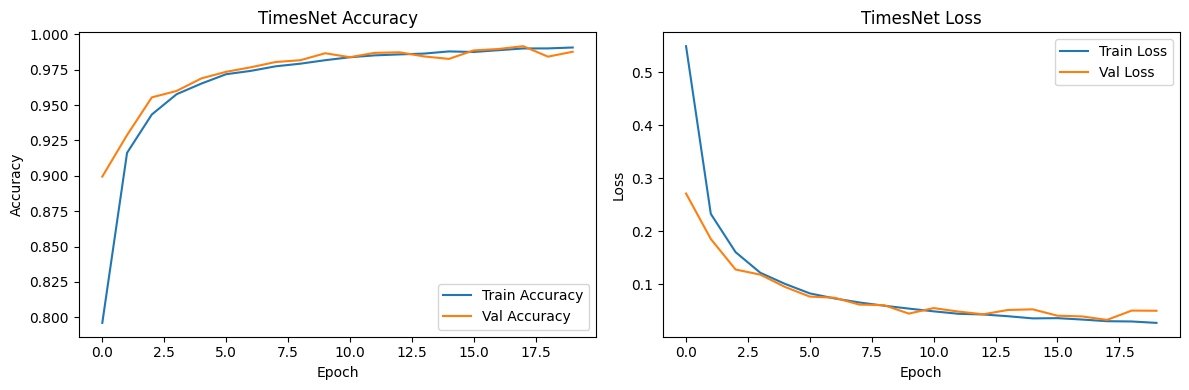

In [23]:
# Visualisasi Hasil Pelatihan TimesNet
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_timesnet.history['accuracy'], label='Train Accuracy')
plt.plot(history_timesnet.history['val_accuracy'], label='Val Accuracy')
plt.title('TimesNet Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_timesnet.history['loss'], label='Train Loss')
plt.plot(history_timesnet.history['val_loss'], label='Val Loss')
plt.title('TimesNet Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
# Evaluasi Model TimesNet pada Test Set
start_time = time.time()
y_pred_ohe = timesnet_model.predict(X_test)
end_time = time.time()

total_time_tn = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Hasil Evaluasi Dasar
loss_tn, accuracy_tn = timesnet_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss_tn:.4f}")
print(f"Test Accuracy: {accuracy_tn:.4f}")
print(f"Total Prediction Time: {total_time_tn:.2f} detik")

print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step
Test Loss: 0.0338
Test Accuracy: 0.9912
Total Prediction Time: 24.90 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.993     0.970     0.981      3000
Supraventricular      0.979     0.998     0.988      3000
     Ventricular      0.995     0.990     0.992      3000
          Fusion      0.991     1.000     0.996      3000
         Unknown      0.998     0.999     0.998      3000

        accuracy                          0.991     15000
       macro avg      0.991     0.991     0.991     15000
    weighted avg      0.991     0.991     0.991     15000



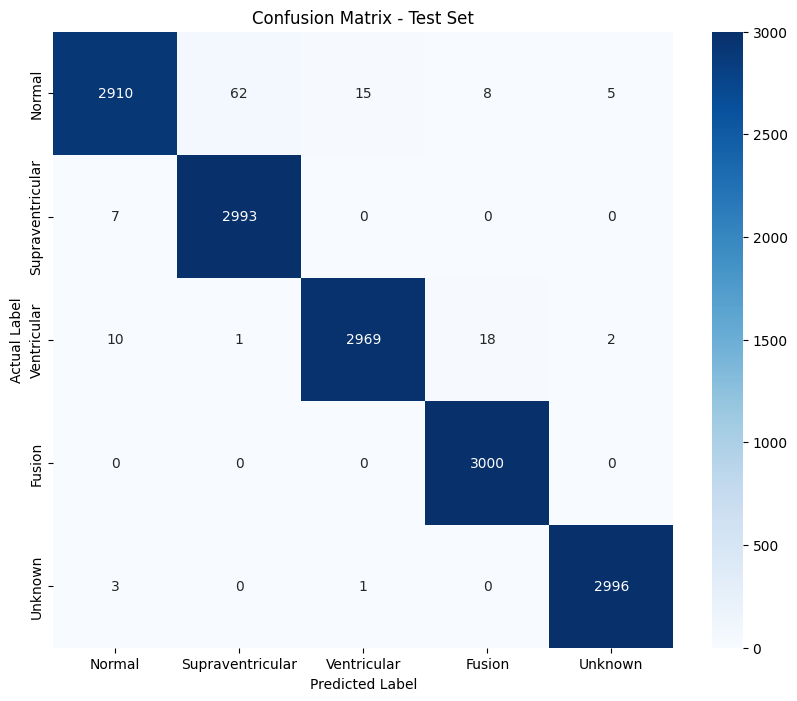

In [25]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

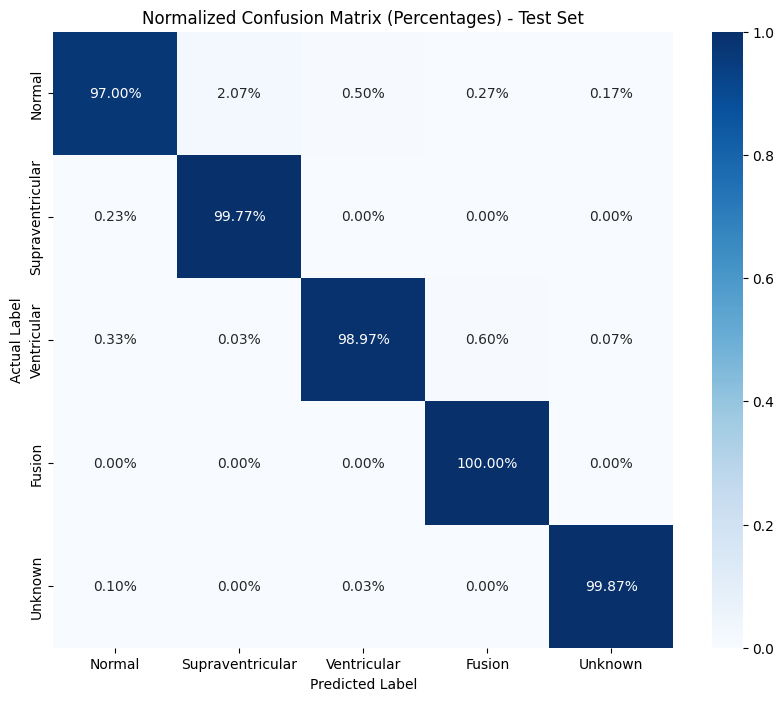

In [26]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Training Model (2)

In [13]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate2 = 0.005
epochs = 20
batch_size = 32

timesnet_model.compile(
    optimizer=Adam(learning_rate=learning_rate2),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history2 = timesnet_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.6629 - loss: 0.9096
Epoch 1: val_accuracy improved from None to 0.86013, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 696s 316ms/step - accuracy: 0.7515 - loss: 0.6674 - val_accuracy: 0.8601 - val_loss: 0.3886
Epoch 2/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.8648 - loss: 0.3680
Epoch 2: val_accuracy improved from 0.86013 to 0.89587, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 672s 307ms/step - accuracy: 0.8805 - loss: 0.3262 - val_accuracy: 0.8959 - val_loss: 0.2771
Epoch 3/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.9142 - loss: 0.2386
Epoch 3: val_accuracy improved from 0.89587 to 0.93667, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 675s 308ms/step - accuracy: 0.918

# Evaluasi Metrik (2)

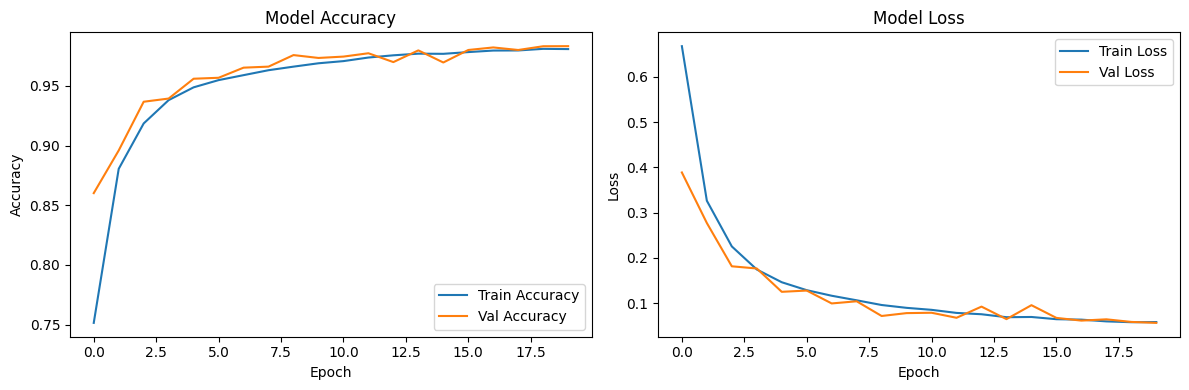

In [14]:
# Visualisasi Hasil Pelatihan
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = timesnet_model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time2 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss2, accuracy2 = timesnet_model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate2}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss2:.4f}")
print(f"Test Accuracy: {accuracy2:.4f}")
print(f"Total Prediction Time: {total_time2:.2f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 115ms/step
Learning Rate: 0.005
Epochs: 20
Batch size: 32
Test Loss: 0.0595
Test Accuracy: 0.9821
Total Prediction Time: 55.06 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.967     0.962     0.965      3000
Supraventricular      0.979     0.981     0.980      3000
     Ventricular      0.995     0.970     0.982      3000
          Fusion      0.974     1.000     0.987      3000
         Unknown      0.995     0.998     0.996      3000

        accuracy                          0.982     15000
       macro avg      0.982     0.982     0.982     15000
    weighted avg      0.982     0.982     0.982     15000



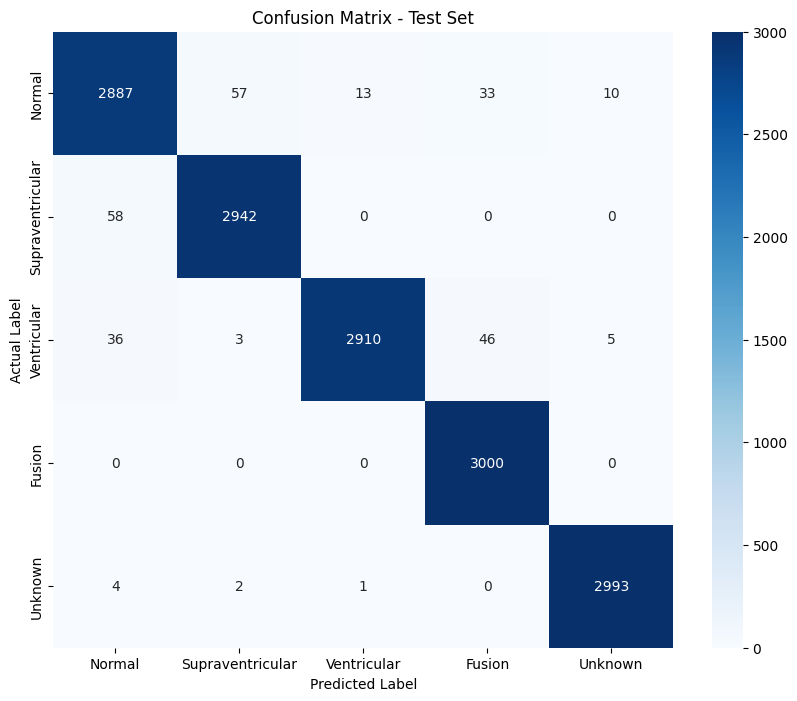

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

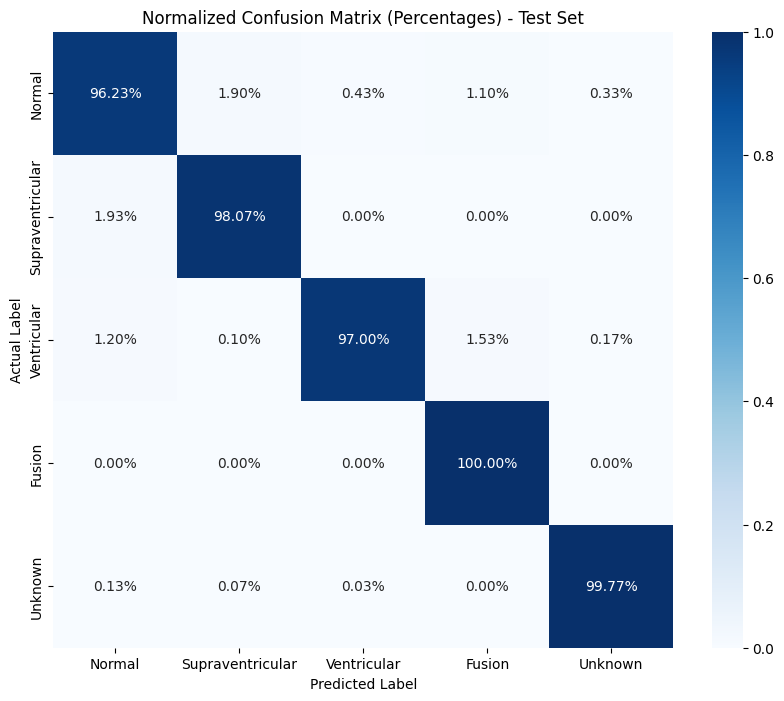

In [17]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Training Model (3)


In [13]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate3 = 0.001
epochs = 20
batch_size = 32

timesnet_model.compile(
    optimizer=Adam(learning_rate=learning_rate3),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history = timesnet_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5589 - loss: 1.1093
Epoch 1: val_accuracy improved from None to 0.75827, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 82s 36ms/step - accuracy: 0.6518 - loss: 0.9187 - val_accuracy: 0.7583 - val_loss: 0.6372
Epoch 2/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7793 - loss: 0.6063
Epoch 2: val_accuracy improved from 0.75827 to 0.81940, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 69s 32ms/step - accuracy: 0.7892 - loss: 0.5736 - val_accuracy: 0.8194 - val_loss: 0.4954
Epoch 3/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8217 - loss: 0.4816
Epoch 3: val_accuracy improved from 0.81940 to 0.85740, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 68s 31ms/step - accuracy: 0.8300 - loss:

# Evaluasi Metrik (3)


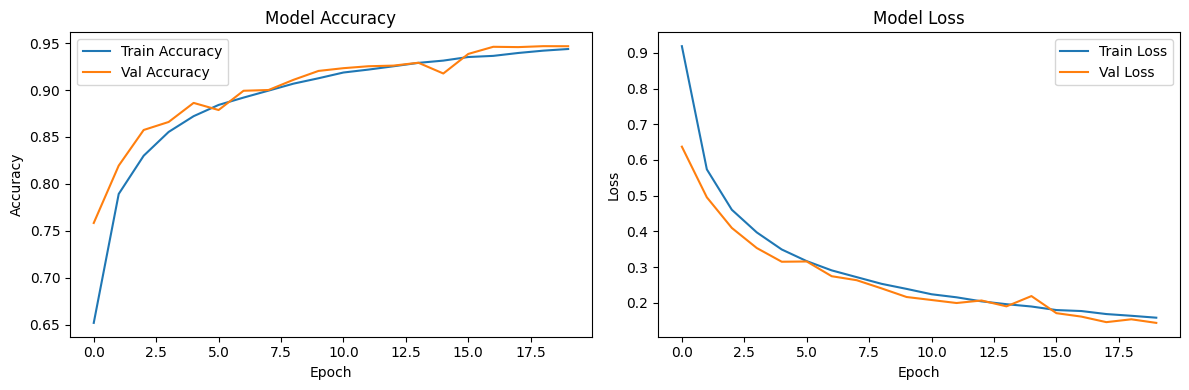

In [14]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = timesnet_model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time3 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss3, accuracy3 = timesnet_model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate3}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss3:.4f}")
print(f"Test Accuracy: {accuracy3:.4f}")
print(f"Total Prediction Time: {total_time3:.2f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step
Learning Rate: 0.001
Epochs: 20
Batch size: 32
Test Loss: 0.1459
Test Accuracy: 0.9478
Total Prediction Time: 7.34 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.894     0.916     0.905      3000
Supraventricular      0.940     0.901     0.920      3000
     Ventricular      0.949     0.965     0.957      3000
          Fusion      0.966     0.968     0.967      3000
         Unknown      0.990     0.989     0.989      3000

        accuracy                          0.948     15000
       macro avg      0.948     0.948     0.948     15000
    weighted avg      0.948     0.948     0.948     15000



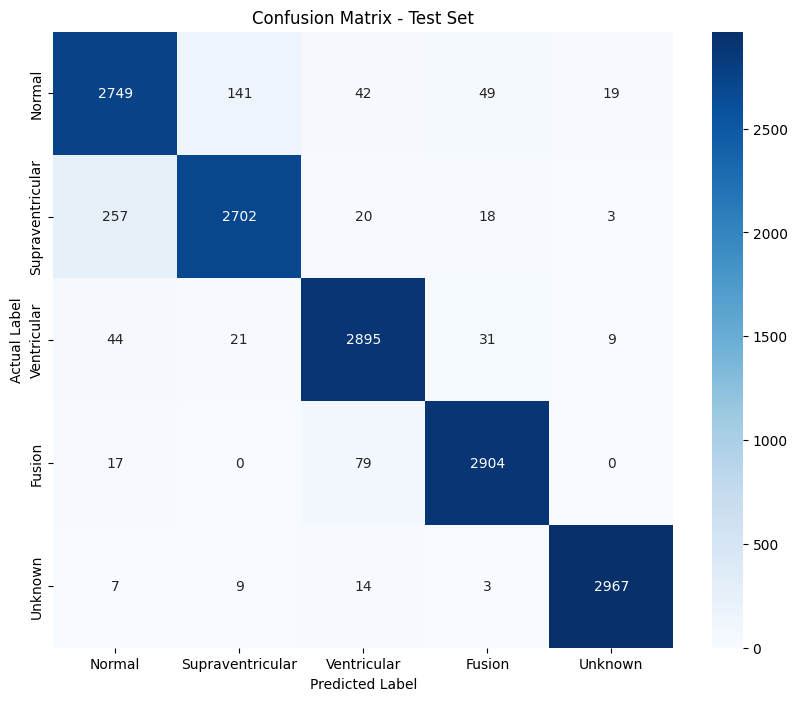

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

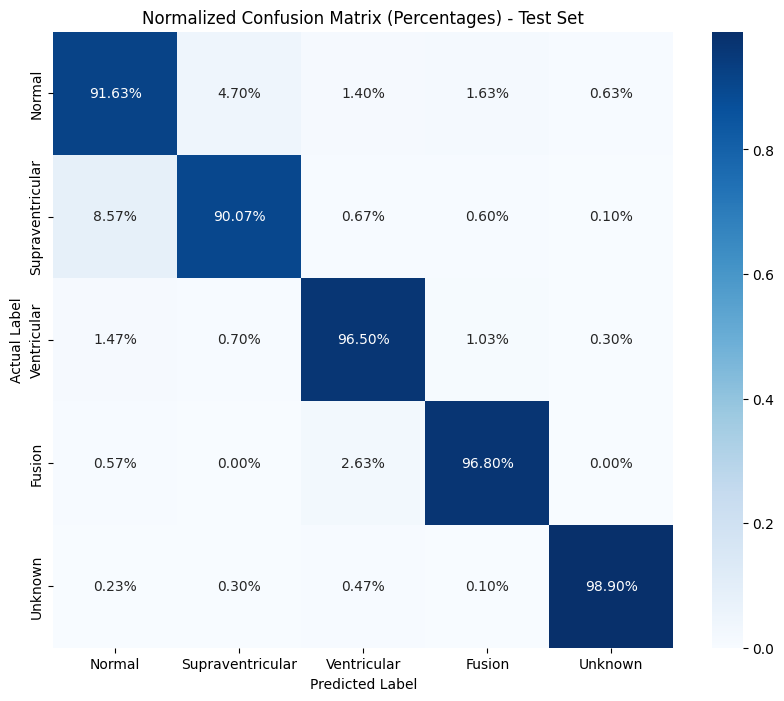

In [17]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Training Model (4)

In [18]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate4 = 0.0005
epochs = 20
batch_size = 32

timesnet_model.compile(
    optimizer=Adam(learning_rate=learning_rate4),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history = timesnet_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9536 - loss: 0.1344
Epoch 1: val_accuracy improved from None to 0.95833, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 102s 45ms/step - accuracy: 0.9531 - loss: 0.1343 - val_accuracy: 0.9583 - val_loss: 0.1264
Epoch 2/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9551 - loss: 0.1284
Epoch 2: val_accuracy improved from 0.95833 to 0.96013, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 77s 35ms/step - accuracy: 0.9537 - loss: 0.1324 - val_accuracy: 0.9601 - val_loss: 0.1223
Epoch 3/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9552 - loss: 0.1289
Epoch 3: val_accuracy did not improve from 0.96013
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 80s 36ms/step - accuracy: 0.9549 - loss: 0.1293 - val_accuracy: 0.9595 - val_loss: 0.1202
Epoch 4/20
2186/2188 ━━━━━━━━━━━━━━━━━━

# Evaluasi Metrik (4)

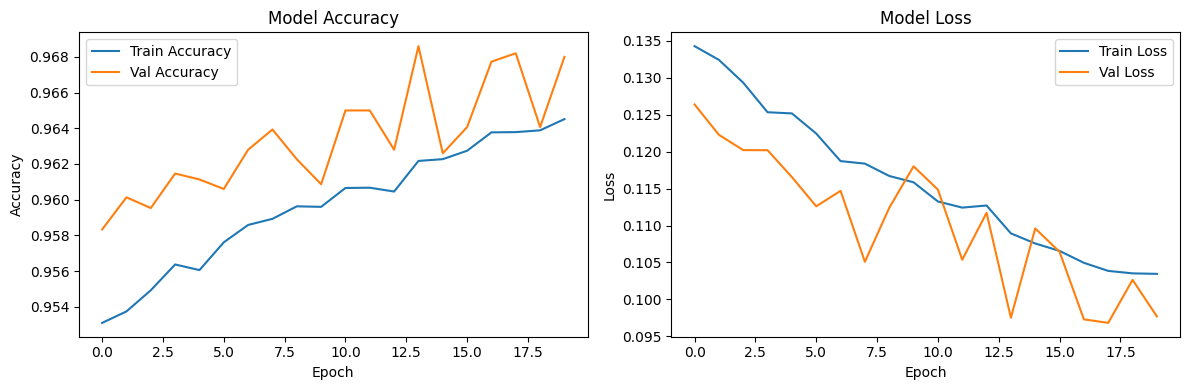

In [19]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = timesnet_model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time4 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss4, accuracy4 = timesnet_model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate4}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss4:.4f}")
print(f"Test Accuracy: {accuracy4:.4f}")
print(f"Total Prediction Time: {total_time4:.2f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step
Learning Rate: 0.0005
Epochs: 20
Batch size: 32
Test Loss: 0.1049
Test Accuracy: 0.9653
Total Prediction Time: 4.79 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.932     0.933     0.933      3000
Supraventricular      0.958     0.939     0.949      3000
     Ventricular      0.967     0.975     0.971      3000
          Fusion      0.982     0.985     0.984      3000
         Unknown      0.987     0.995     0.991      3000

        accuracy                          0.965     15000
       macro avg      0.965     0.965     0.965     15000
    weighted avg      0.965     0.965     0.965     15000



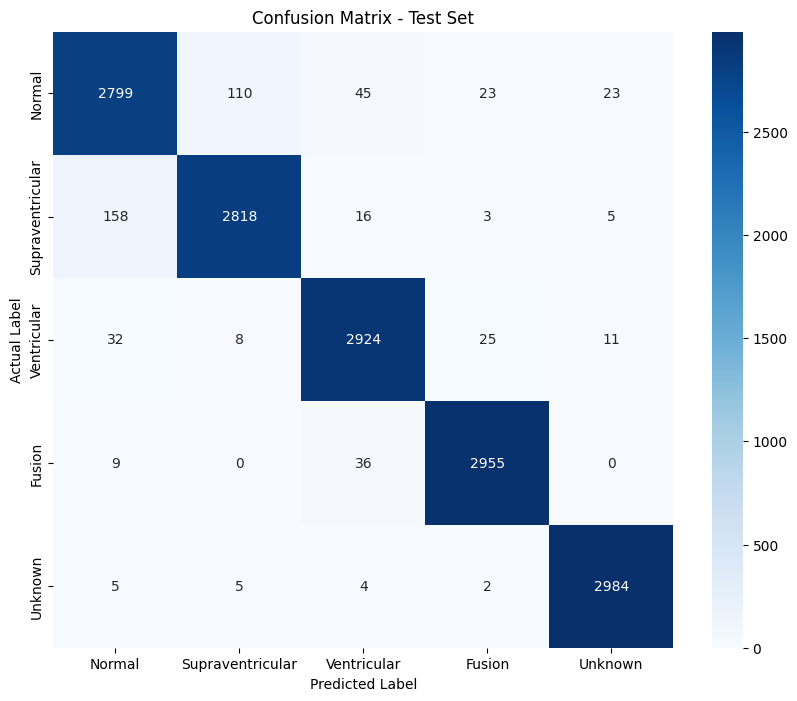

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

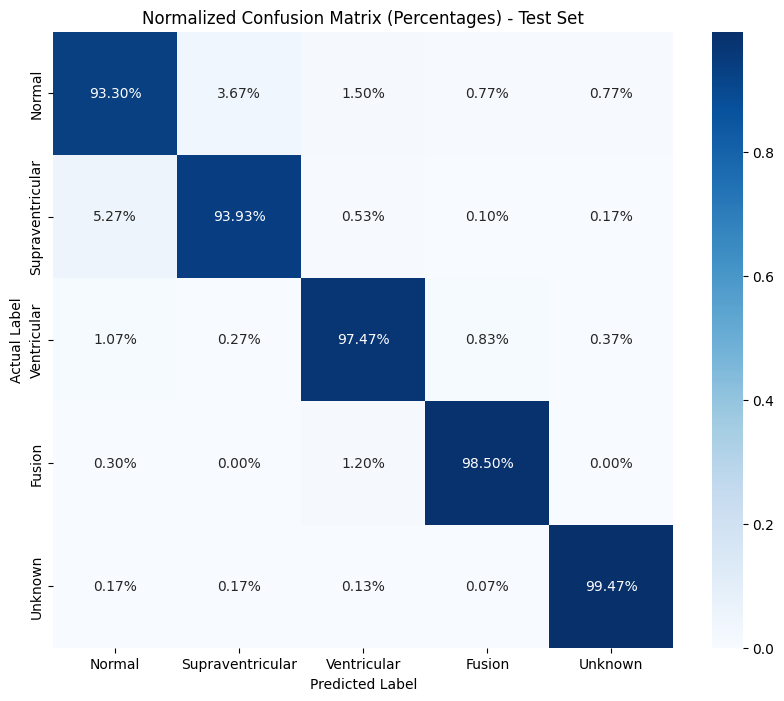

In [22]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Membuat data untuk tabel ringkasan
data = {
  'Model': ['Timesnet'],
  'Learning Rate': [learning_rate1, learning_rate2, learning_rate3, learning_rate4],
  'Epochs': [epochs, epochs, epochs, epochs],
  'Batch Size': [batch_size, batch_size, batch_size, batch_size],
  'Test Loss': [f"{loss1:.4f}", f"{loss2:.4f}", f"{loss3:.4f}", f"{loss4:.4f}"],
  'Test Accuracy': [f"{accuracy1*100:.2f}%", f"{accuracy2*100:.2f}%", f"{accuracy3*100:.2f}%", f"{accuracy4*100:.2f}%"],
  'Eval Runtime (Detik)': [total_time1, total_time2, total_time3, total_time4]
}

df_summary = pd.DataFrame(data)
print("Summary Statistik Performa Model ViT:")
display(df_summary)

# Penyimpanan dan Deployment

In [ ]:
# 1. Simpan Model TimesNet
timesnet_model.save('mitbih_timesnet.keras')
print("Model berhasil disimpan sebagai 'mitbih_timesnet.keras'")

# 2. Simpan OneHotEncoder
with open('encoder.pkl', 'wb') as f:
    pickle.dump(ohe, f)
print("Encoder berhasil disimpan sebagai 'encoder.pkl'")

Model berhasil disimpan sebagai 'mitbih_cnn_model.keras'
Encoder berhasil disimpan sebagai 'encoder.pkl'
